# 08 — Metric, Normed, Banach & Hilbert Spaces

> *What each layer of structure actually buys you, demonstrated by breaking it.*

## The one-paragraph answer

A **Hilbert space is not a generalisation of your linear-algebra intuition — it is the
precise list of conditions under which that intuition survives.**

In $\mathbb{R}^3$ you get dot products, lengths, angles, orthogonality and projection for
free. Move to infinite dimensions — where a "vector" is a *function* — and almost all of it
breaks. Hilbert space is the name for the setting where **none** of it breaks.

That is also why the axioms feel like bureaucracy when you first meet them. Every
distinction in the hierarchy is **automatic in finite dimensions**:

| Property | Finite dim | Infinite dim |
|---|---|---|
| Complete (Cauchy sequences converge) | automatic | must be assumed → **Banach** |
| Every subspace is closed | automatic | **false** |
| All norms are equivalent | automatic | **false** |
| Closed + bounded $\Rightarrow$ compact | automatic | **false** |
| Linear maps are continuous | automatic | **false** |
| Norm comes from an inner product | *depends on the norm* | *depends on the norm* → **Hilbert** |

You have only ever seen the case where it is all free, so the axioms look like they are
solving a problem that does not exist. They are not. This notebook builds the
counterexamples in code.

## How to read this

We do **not** march through definitions. We start from one concrete problem —
*"approximate a complicated function by simple pieces"* — and add exactly the structure
each step requires, showing what fails without it.

| § | Layer | What it adds | What still breaks |
|---|---|---|---|
| 2 | **Metric space** | distance | no algebra, no length, no angle |
| 3 | **Normed space** | length + vector algebra | angles; projection can be non-unique |
| 4 | **Banach space** | completeness | still no angles |
| 5 | **Hilbert space** | inner product $\Rightarrow$ angles | — |
| 6–8 | payoffs | Pythagoras, projection, bases, Riesz | |
| 9 | RKHS | the kernel trick *is* a Hilbert space | |
| 10 | Lie algebras | a different axis entirely | |

**Related notebooks:** 05 (measure theory, $L^p$ construction) and 06 (quantum mechanics,
Hilbert spaces in anger). This notebook is the structural backbone both of those lean on.

---
## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import quad
from scipy.linalg import expm, norm as sla_norm
from numpy.polynomial import legendre

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'figure.dpi': 100
})
sns.set_style("whitegrid")
np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

# numpy renamed trapz -> trapezoid in 2.0; keep one name for both
trapz = getattr(np, "trapezoid", None) or np.trapz

print(f"numpy {np.__version__}")

numpy 2.2.6


### 1.1 The problem we are actually trying to solve

Take a square wave on $[-\pi, \pi]$ and approximate it with sines:

$$ f(x) \;\approx\; \sum_{k \text{ odd}}^{N} \frac{4}{\pi k}\sin(kx) $$

This works. The question this whole notebook answers is **why** — and what would have to
be true for it to stop working.

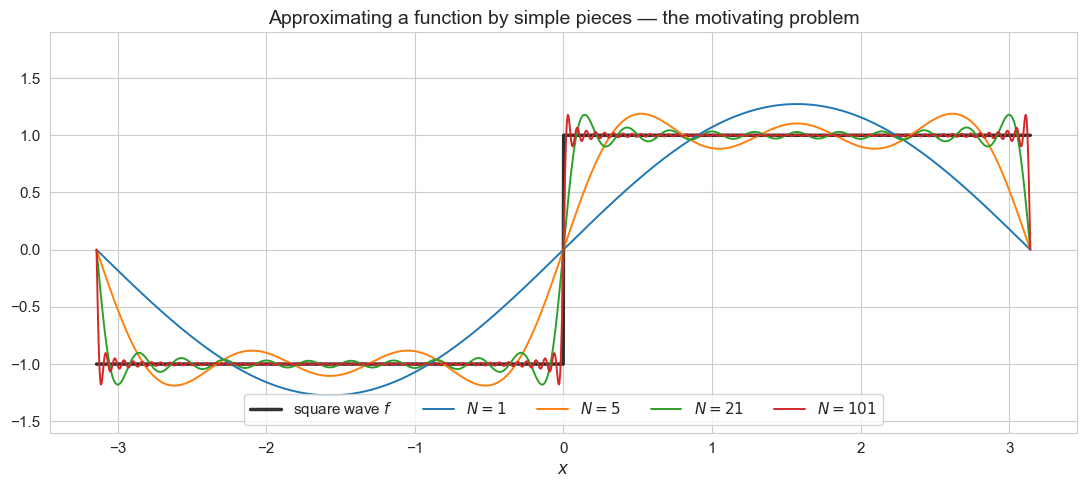

Three things are quietly being assumed here:
  1. 'distance' between two FUNCTIONS means something   -> metric
  2. sin(kx) are 'perpendicular' so coefficients decouple -> inner product
  3. the infinite sum CONVERGES TO SOMETHING IN THE SPACE -> completeness


In [2]:
x = np.linspace(-np.pi, np.pi, 2000)
square = np.sign(np.sin(x))

def fourier_square(x, N):
    # Partial sum of the square-wave Fourier series (odd harmonics only)
    out = np.zeros_like(x)
    for k in range(1, N + 1, 2):
        out += (4 / (np.pi * k)) * np.sin(k * x)
    return out

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, square, 'k', lw=2.5, label='square wave $f$', alpha=0.8)
for N, c in [(1, 'C0'), (5, 'C1'), (21, 'C2'), (101, 'C3')]:
    ax.plot(x, fourier_square(x, N), c, lw=1.4, label=f'$N={N}$')
ax.set_title("Approximating a function by simple pieces — the motivating problem")
ax.set_xlabel("$x$"); ax.legend(ncol=5, loc='lower center'); ax.set_ylim(-1.6, 1.9)
plt.tight_layout(); plt.show()

print("Three things are quietly being assumed here:")
print("  1. 'distance' between two FUNCTIONS means something   -> metric")
print("  2. sin(kx) are 'perpendicular' so coefficients decouple -> inner product")
print("  3. the infinite sum CONVERGES TO SOMETHING IN THE SPACE -> completeness")

---
## 2. Metric space — distance, and nothing else

A **metric space** $(X, d)$ is a set with a distance $d: X\times X \to \mathbb{R}_{\ge 0}$ satisfying

$$d(x,y)=0 \iff x=y, \qquad d(x,y)=d(y,x), \qquad d(x,z) \le d(x,y)+d(y,z)$$

Note what is **absent**: $X$ is just a *set*. There is no addition, no scalar multiplication,
no origin. You cannot ask "what is $2x$" or "what is $x+y$", because those symbols are undefined.

The only thing a metric gives you is **convergence** — the ability to say a sequence
settles down. That is genuinely useful, and genuinely limited.

In [3]:
# A metric space with no algebra whatsoever: strings under edit distance.
def edit_distance(a, b):
    m, n = len(a), len(b)
    D = np.zeros((m + 1, n + 1), dtype=int)
    D[:, 0] = np.arange(m + 1)
    D[0, :] = np.arange(n + 1)
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            D[i, j] = min(D[i-1, j] + 1,
                          D[i, j-1] + 1,
                          D[i-1, j-1] + (a[i-1] != b[j-1]))
    return D[m, n]

words = ["kitten", "sitten", "sitting", "mitten", "flitting"]
print("Edit-distance matrix (a perfectly good metric):\n")
print("          " + "".join(f"{w:>10}" for w in words))
for a in words:
    print(f"{a:>10}" + "".join(f"{edit_distance(a,b):>10}" for b in words))

# triangle inequality holds
viol = [(a,b,c) for a in words for b in words for c in words
        if edit_distance(a,c) > edit_distance(a,b) + edit_distance(b,c)]
print(f"\nTriangle-inequality violations: {len(viol)}  -> it is a genuine metric")

print("\nBut now try to do linear algebra:")
print("   'kitten' + 'mitten' = ?     undefined")
print("   2 * 'kitten'        = ?     undefined")
print("   angle('kitten','mitten') = ? undefined")
print("\n=> A metric alone cannot support ANY of the Fourier machinery above.")

Edit-distance matrix (a perfectly good metric):

              kitten    sitten   sitting    mitten  flitting
    kitten         0         1         3         1         4
    sitten         1         0         2         1         4
   sitting         3         2         0         3         2
    mitten         1         1         3         0         4
  flitting         4         4         2         4         0

Triangle-inequality violations: 0  -> it is a genuine metric

But now try to do linear algebra:
   'kitten' + 'mitten' = ?     undefined
   2 * 'kitten'        = ?     undefined
   angle('kitten','mitten') = ? undefined

=> A metric alone cannot support ANY of the Fourier machinery above.


**What section 2 established.** Distance is enough to talk about limits and continuity.
It is not enough to *build* anything: there is no way to form $\sum_k c_k \phi_k$, because
neither $+$ nor scalar multiplication exists. We need a vector space.

---
## 3. Normed space — length, and therefore algebra

A **normed vector space** is a vector space $V$ with $\|\cdot\|: V \to \mathbb{R}_{\ge 0}$ where

$$\|v\| = 0 \iff v=0, \qquad \|\alpha v\| = |\alpha|\,\|v\|, \qquad \|u+v\| \le \|u\| + \|v\|$$

Every norm induces a metric via $d(u,v) = \|u-v\|$ — so a normed space *is* a metric space,
but one where the distance is compatible with the algebra.

The family we will use throughout is the **$p$-norms**:

$$\|v\|_p = \Big(\sum_i |v_i|^p\Big)^{1/p}, \qquad \|v\|_\infty = \max_i |v_i|$$

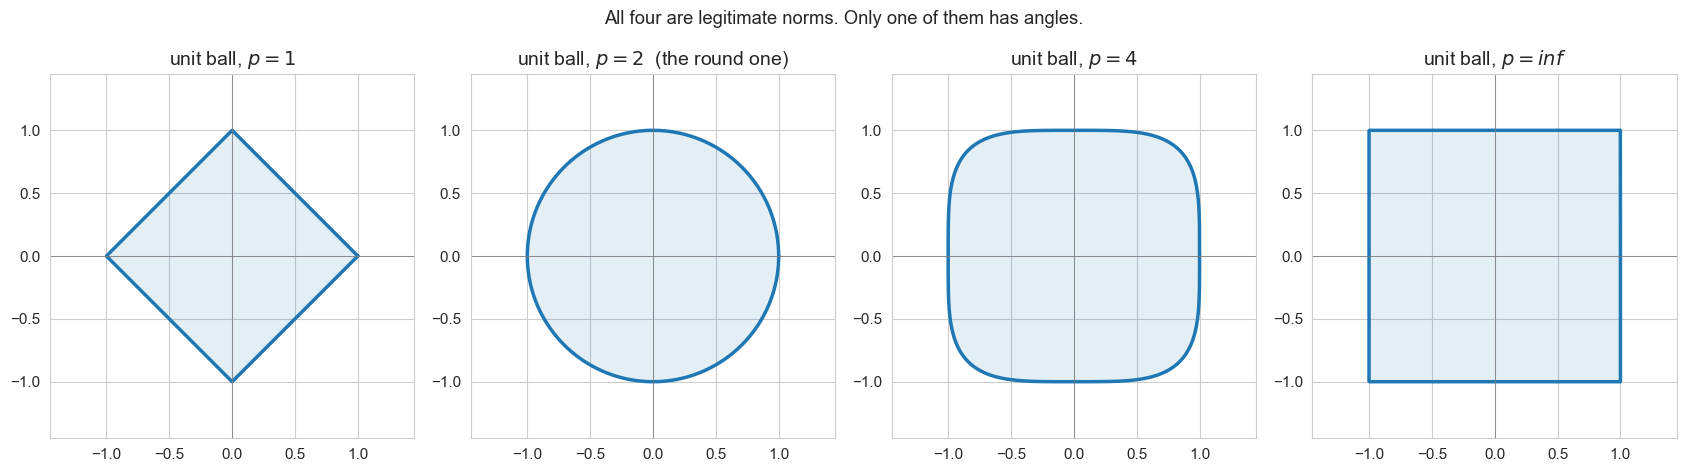

v = [3. 4.]
   ||v||_1    = 7.0000
   ||v||_2    = 5.0000
   ||v||_4    = 4.2846
   ||v||_inf  = 4.0000


In [4]:
def pnorm(v, p):
    v = np.asarray(v, dtype=float)
    if np.isinf(p):
        return np.max(np.abs(v))
    return np.sum(np.abs(v) ** p) ** (1.0 / p)

# The unit ball {v : ||v||_p = 1} looks completely different for different p.
theta = np.linspace(0, 2 * np.pi, 2000)
circle = np.vstack([np.cos(theta), np.sin(theta)])

fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
for ax, p in zip(axes, [1, 2, 4, np.inf]):
    scale = np.array([pnorm(circle[:, i], p) for i in range(circle.shape[1])])
    ball = circle / scale
    ax.plot(ball[0], ball[1], lw=2.5, color='C0')
    ax.fill(ball[0], ball[1], alpha=0.12, color='C0')
    ax.set_aspect('equal'); ax.set_xlim(-1.45, 1.45); ax.set_ylim(-1.45, 1.45)
    ax.axhline(0, color='grey', lw=0.6); ax.axvline(0, color='grey', lw=0.6)
    ax.set_title(f"unit ball, $p={p}$" + ("  (the round one)" if p == 2 else ""))
plt.suptitle("All four are legitimate norms. Only one of them has angles.", y=1.02)
plt.tight_layout(); plt.show()

v = np.array([3.0, 4.0])
print(f"v = {v}")
for p in [1, 2, 4, np.inf]:
    print(f"   ||v||_{p!s:<4} = {pnorm(v, p):.4f}")

### 3.1 The first real crack: "closest point" can be ambiguous

Here is the first thing that genuinely breaks, and it breaks *in two dimensions* — no
infinite-dimensional exotica required.

**Question:** given a point $q$ and a line $L$, what is the closest point of $L$ to $q$?

In the 2-norm the answer is always unique — the perpendicular foot. In the 1- and
$\infty$-norms **an entire segment of the line can be tied for closest**, because those
unit balls have *flat faces*: slide the ball outwards and it touches the line along a whole
edge rather than at a point.

Which norm fails depends on how the line is oriented, so we test **two** lines below.
The 2-norm is unique in both; each of the others fails on one of them.

This matters far beyond geometry: it is the difference between ordinary least squares
having one answer, and $L^1$ regression (least absolute deviations) having a whole set of them.

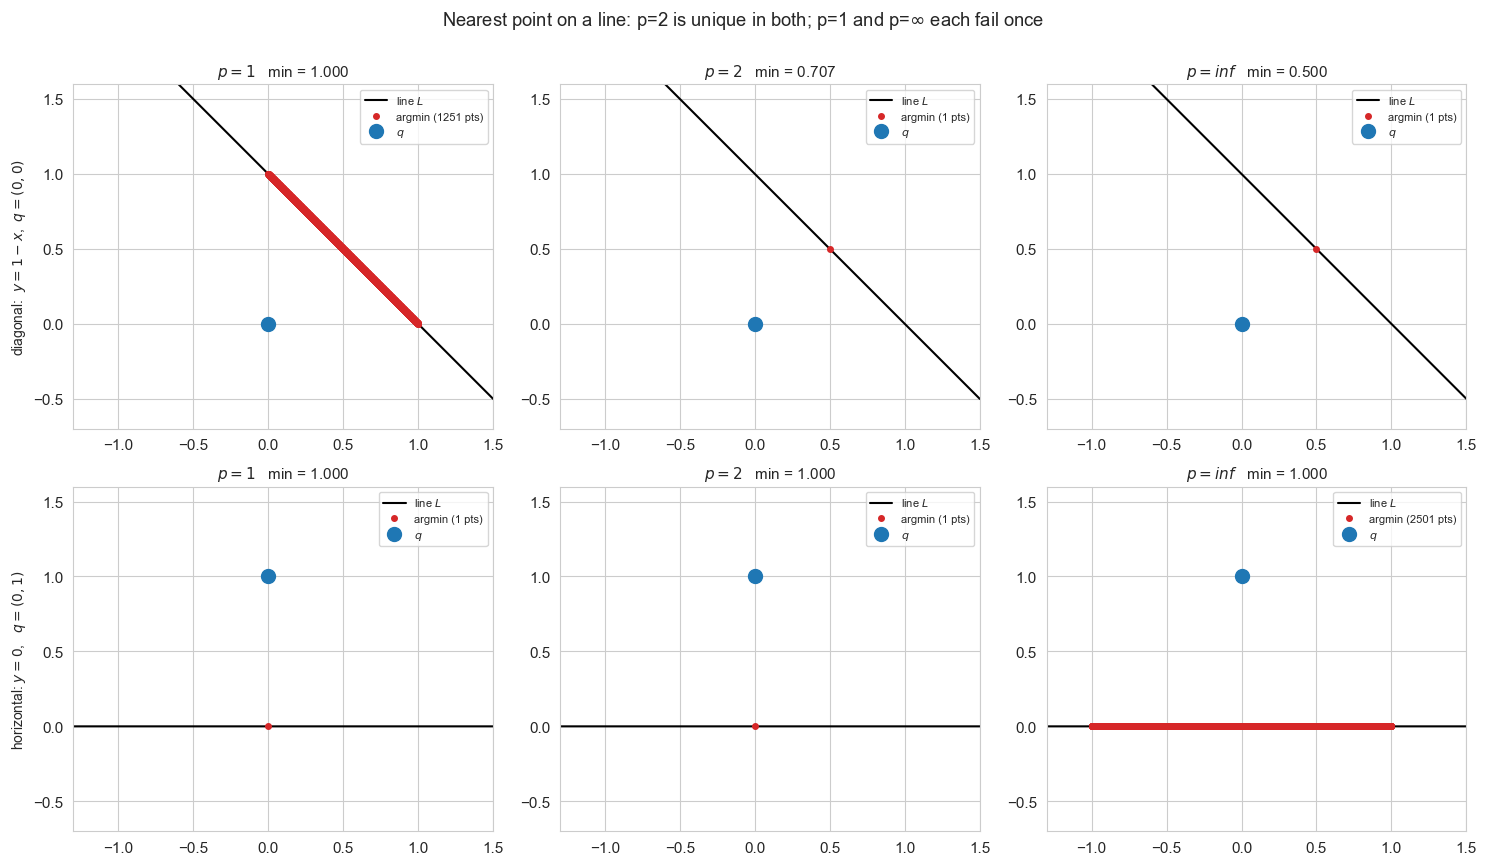

configuration                                  p=1         p=2           p=inf
------------------------------------------------------------------------------
diagonal                                TIED(1251)      UNIQUE          UNIQUE
horizontal                                  UNIQUE      UNIQUE      TIED(2501)

p=2 is the only column that is UNIQUE in every row. That is not a coincidence --
it is the projection theorem, and it needs an inner product (section 5).


In [5]:
def tied_count(L, q, p, tol=1e-9):
    d = np.array([pnorm(L[:, i] - q, p) for i in range(L.shape[1])])
    return d, (np.abs(d - d.min()) < tol)

t = np.linspace(-1.6, 1.6, 4001)
configs = [("diagonal:  $y = 1-x$,  $q=(0,0)$", np.vstack([t, 1 - t]), np.array([0.0, 0.0])),
           ("horizontal: $y = 0$,   $q=(0,1)$", np.vstack([t, np.zeros_like(t)]), np.array([0.0, 1.0]))]

fig, axes = plt.subplots(2, 3, figsize=(15, 8.6))
for row, (name, L, q) in enumerate(configs):
    for ax, p in zip(axes[row], [1, 2, np.inf]):
        d, tied = tied_count(L, q, p)
        ax.plot(L[0], L[1], 'k-', lw=1.5, label='line $L$')
        ax.plot(L[0][tied], L[1][tied], 'o', color='C3', ms=4, label=f'argmin ({tied.sum()} pts)')
        ax.plot(*q, 'o', color='C0', ms=10, label='$q$')
        ax.set_aspect('equal'); ax.set_xlim(-1.3, 1.5); ax.set_ylim(-0.7, 1.6)
        ax.set_title(f"$p={p}$   min = {d.min():.3f}", fontsize=11)
        ax.legend(loc='upper right', fontsize=8)
    axes[row][0].set_ylabel(name, fontsize=10)
plt.suptitle("Nearest point on a line: p=2 is unique in both; p=1 and p=$\\infty$ each fail once", y=1.00)
plt.tight_layout(); plt.show()

print(f"{'configuration':<34}{'p=1':>16}{'p=2':>12}{'p=inf':>16}")
print("-" * 78)
for name, L, q in configs:
    cells = []
    for p in [1, 2, np.inf]:
        n = tied_count(L, q, p)[1].sum()
        cells.append("UNIQUE" if n <= 2 else f"TIED({n})")
    plain = name.split(':')[0]
    print(f"{plain:<34}{cells[0]:>16}{cells[1]:>12}{cells[2]:>16}")
print("\np=2 is the only column that is UNIQUE in every row. That is not a coincidence --")
print("it is the projection theorem, and it needs an inner product (section 5).")

**What section 3 established.** A norm gives length and lets us do algebra, so
$\sum_k c_k \phi_k$ now parses. But "closest point" — the operation that *defines*
approximation — need not have a unique answer. We have not yet earned the right to
say "the best approximation".

---
## 4. Banach space — completeness, or: does the limit stay in the room?

A normed space is **complete** (a **Banach space**) if every Cauchy sequence converges
*to an element of the space*.

In finite dimensions this is free — $\mathbb{R}^n$ is complete, and so is every
finite-dimensional normed space, whatever norm you pick. So the condition never comes up
in a linear algebra course. In infinite dimensions it is a real constraint that real
spaces fail.

The classic small example is $\mathbb{Q}$: the sequence $1, 1.4, 1.41, 1.414,\dots$ is
Cauchy under $|\cdot|$ but its limit $\sqrt2$ is **not rational**. The sequence converges
"to a hole".

In [6]:
# Newton iteration for sqrt(2), kept exactly rational with Fraction.
from fractions import Fraction

xq = Fraction(1)
rows = []
for n in range(6):
    rows.append((n, xq, float(xq), abs(float(xq) - np.sqrt(2))))
    xq = (xq + Fraction(2, 1) / xq) / 2

print(f"{'n':>2}  {'x_n (exact rational)':>28}  {'float':>12}  {'|x_n - sqrt2|':>14}")
for n, fr, fl, err in rows:
    s = f"{fr.numerator}/{fr.denominator}"
    print(f"{n:>2}  {s:>28}  {fl:>12.9f}  {err:>14.3e}")

print("\nEvery x_n is rational. The gaps |x_n - x_m| -> 0, so the sequence is Cauchy.")
print("The limit sqrt(2) is irrational => Q is NOT complete. The limit left the space.")

 n          x_n (exact rational)         float   |x_n - sqrt2|
 0                           1/1   1.000000000       4.142e-01
 1                           3/2   1.500000000       8.579e-02
 2                         17/12   1.416666667       2.453e-03
 3                       577/408   1.414215686       2.124e-06
 4                 665857/470832   1.414213562       1.595e-12
 5     886731088897/627013566048   1.414213562       0.000e+00

Every x_n is rational. The gaps |x_n - x_m| -> 0, so the sequence is Cauchy.
The limit sqrt(2) is irrational => Q is NOT complete. The limit left the space.


### 4.1 The same failure, for functions

Now the version that matters. Take $C[-1,1]$, the **continuous** functions, and measure
distance with the $L^1$ norm $\;\|f\|_1 = \int_{-1}^{1}|f|\,dx$.

Define a sequence of continuous ramps $f_n$ that get steeper and steeper, tending to a
step function. Each $f_n$ is continuous. The sequence is Cauchy in $\|\cdot\|_1$. But the
limit is a **step function — discontinuous**, so it is *not in $C[-1,1]$*.

$\big(C[-1,1], \|\cdot\|_1\big)$ is a perfectly good normed space that is **not complete**.

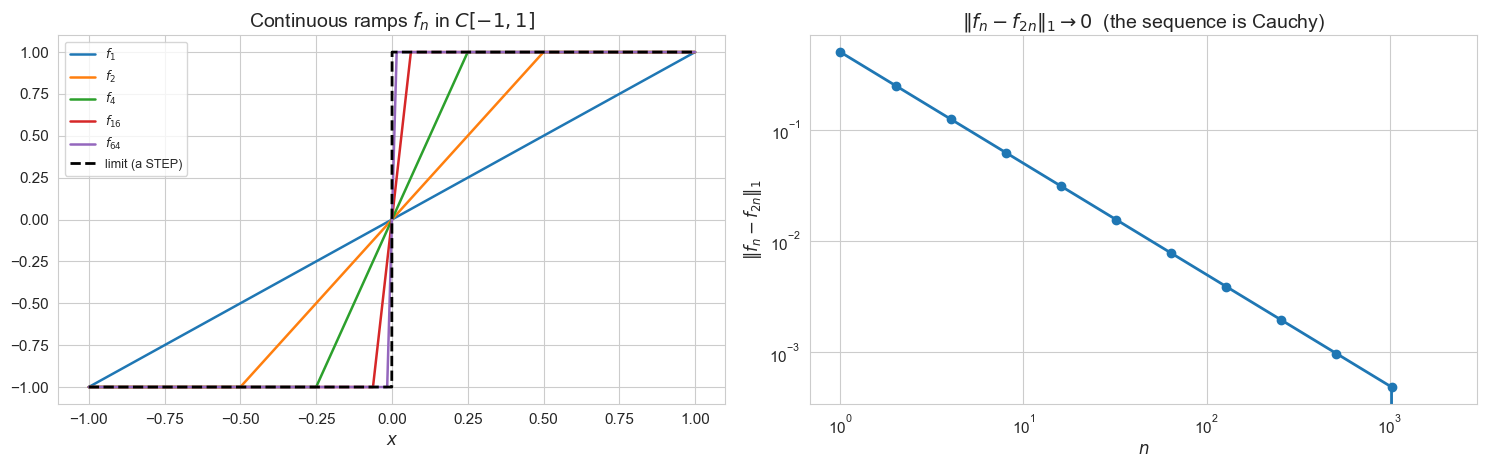

||f_n - f_2n||_1 at n=1    : 0.500000
||f_n - f_2n||_1 at n=2048 : 0.000000e+00   -> Cauchy
||f_n - sign||_1 at n=2048 : 0.000000e+00   -> converging

But sign(x) is DISCONTINUOUS, so the limit is not in C[-1,1].
=> (C[-1,1], L1) is normed but NOT complete: not a Banach space.
   L^1[-1,1] (measure-theoretic, see notebook 05) IS the completion.


In [7]:
def ramp(x, n):
    # continuous approximation to the step function sign(x), slope n
    return np.clip(n * x, -1, 1)

xs = np.linspace(-1, 1, 4001)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for n in [1, 2, 4, 16, 64]:
    axes[0].plot(xs, ramp(xs, n), lw=1.8, label=f'$f_{{{n}}}$')
axes[0].plot(xs, np.sign(xs), 'k--', lw=2, label='limit (a STEP)')
axes[0].set_title("Continuous ramps $f_n$ in $C[-1,1]$")
axes[0].legend(fontsize=9); axes[0].set_xlabel("$x$")

# Cauchy in L1?  ||f_n - f_m||_1 -> 0 as both grow
def L1(f, g):
    return trapz(np.abs(f - g), xs)

ns = 2 ** np.arange(0, 12)
gaps = [L1(ramp(xs, n), ramp(xs, 2 * n)) for n in ns]
axes[1].loglog(ns, gaps, 'o-', lw=2)
axes[1].set_title(r"$\|f_n - f_{2n}\|_1 \to 0$  (the sequence is Cauchy)")
axes[1].set_xlabel("$n$"); axes[1].set_ylabel(r"$\|f_n-f_{2n}\|_1$")
plt.tight_layout(); plt.show()

print(f"||f_n - f_2n||_1 at n=1    : {gaps[0]:.6f}")
print(f"||f_n - f_2n||_1 at n=2048 : {gaps[-1]:.6e}   -> Cauchy")
print(f"||f_n - sign||_1 at n=2048 : {L1(ramp(xs,2048), np.sign(xs)):.6e}   -> converging")
print("\nBut sign(x) is DISCONTINUOUS, so the limit is not in C[-1,1].")
print("=> (C[-1,1], L1) is normed but NOT complete: not a Banach space.")
print("   L^1[-1,1] (measure-theoretic, see notebook 05) IS the completion.")

**Why you should care.** Every existence proof in analysis, optimisation and PDEs has the
same shape: *build a sequence of approximations, show it is Cauchy, conclude the limit
exists*. That last step is **only valid in a complete space.** Without completeness you
can construct better and better approximations to an object that does not exist.

That is exactly what completeness buys — and it is all it buys. A Banach space still has
**no notion of angle**.

---
## 5. Hilbert space — the inner product, and the return of geometry

An **inner product** $\langle\cdot,\cdot\rangle$ is the extra structure that restores angles:

$$\langle u,v\rangle = \overline{\langle v,u\rangle}, \qquad
\langle \alpha u + \beta w, v\rangle = \alpha\langle u,v\rangle + \beta\langle w,v\rangle,
\qquad \langle v,v\rangle \ge 0$$

It induces a norm, $\|v\| = \sqrt{\langle v,v\rangle}$, and therefore an angle:

$$\cos\theta = \frac{\langle u,v\rangle}{\|u\|\,\|v\|}$$

> **Hilbert space = inner product space that is complete.**
> Equivalently: a Banach space whose norm happens to come from an inner product.

### 5.1 The parallelogram law — the exact test

Not every norm comes from an inner product. There is a clean, checkable criterion
(**Jordan–von Neumann**): a norm is induced by an inner product **if and only if**

$$\|u+v\|^2 + \|u-v\|^2 \;=\; 2\|u\|^2 + 2\|v\|^2$$

This is the single sharpest answer to *"what makes Hilbert special among Banach spaces"*,
and it is one line of numpy. Let us just test it.

In [8]:
def parallelogram_defect(p, trials=4000, dim=6, rng=None):
    # max relative violation of the parallelogram law for the p-norm
    rng = rng or np.random.default_rng(0)
    worst = 0.0
    for _ in range(trials):
        u = rng.normal(size=dim)
        v = rng.normal(size=dim)
        lhs = pnorm(u + v, p) ** 2 + pnorm(u - v, p) ** 2
        rhs = 2 * pnorm(u, p) ** 2 + 2 * pnorm(v, p) ** 2
        worst = max(worst, abs(lhs - rhs) / rhs)
    return worst

print("Parallelogram law:  ||u+v||^2 + ||u-v||^2  ==  2||u||^2 + 2||v||^2")
print(f"\n{'p':>6}  {'max relative violation':>24}   verdict")
print("-" * 62)
for p in [1, 1.5, 2, 3, 4, 10, np.inf]:
    d = parallelogram_defect(p)
    verdict = "HOLDS -> inner product exists" if d < 1e-12 else "fails -> Banach only"
    print(f"{str(p):>6}  {d:>24.3e}   {verdict}")

print("\np = 2 is the ONLY one. That is the whole difference between Banach and Hilbert.")

Parallelogram law:  ||u+v||^2 + ||u-v||^2  ==  2||u||^2 + 2||v||^2

     p    max relative violation   verdict
--------------------------------------------------------------
     1                 6.270e-01   fails -> Banach only
   1.5                 1.982e-01   fails -> Banach only
     2                 6.222e-16   HOLDS -> inner product exists
     3                 2.266e-01   fails -> Banach only


     4                 3.653e-01   fails -> Banach only
    10                 6.900e-01   fails -> Banach only
   inf                 8.988e-01   fails -> Banach only

p = 2 is the ONLY one. That is the whole difference between Banach and Hilbert.


In [9]:
# A concrete worked counterexample you can check by hand, in the 1-norm.
u = np.array([1.0, 0.0]); v = np.array([0.0, 1.0])
for p in [1, 2, np.inf]:
    lhs = pnorm(u + v, p)**2 + pnorm(u - v, p)**2
    rhs = 2*pnorm(u, p)**2 + 2*pnorm(v, p)**2
    flag = "==" if abs(lhs - rhs) < 1e-12 else "!="
    print(f"p={str(p):<4}  u=(1,0), v=(0,1):   LHS={lhs:>5.1f} {flag} RHS={rhs:>5.1f}")

print("\nIn the 1-norm: ||u+v||_1 = ||u-v||_1 = 2, so LHS = 8, but RHS = 4.")
print("The parallelogram is 'skewed' -- there is no inner product that produces this norm,")
print("and therefore no consistent notion of angle in (R^2, ||.||_1).")

p=1     u=(1,0), v=(0,1):   LHS=  8.0 != RHS=  4.0
p=2     u=(1,0), v=(0,1):   LHS=  4.0 == RHS=  4.0
p=inf   u=(1,0), v=(0,1):   LHS=  2.0 != RHS=  4.0

In the 1-norm: ||u+v||_1 = ||u-v||_1 = 2, so LHS = 8, but RHS = 4.
The parallelogram is 'skewed' -- there is no inner product that produces this norm,
and therefore no consistent notion of angle in (R^2, ||.||_1).


### 5.2 So what *is* the inner product doing, intuitively?

Nothing new. That is the point worth internalising:

$$\langle u, v\rangle \;=\; \|u\|\,\|v\|\cos\theta$$

is the *same* dot product you already know. The abstraction is not adding exotic
machinery — it is **identifying the minimum you must assume so the familiar picture keeps
holding** when $u$ and $v$ are functions, infinite sequences, or random variables.

Three instances of the identical idea:

| Space | Vectors are | $\langle u,v\rangle$ | "Orthogonal" means |
|---|---|---|---|
| $\mathbb{R}^n$ | arrows | $\sum_i u_i v_i$ | perpendicular |
| $L^2[a,b]$ | functions | $\int_a^b u(x)\overline{v(x)}\,dx$ | no overlap in the integral sense |
| $L^2(\Omega,P)$ | random variables | $\mathbb{E}[UV]$ | **uncorrelated** |

That third row is worth a pause: **uncorrelated random variables are literally
perpendicular vectors**, and the variance decomposition of independent sums is the
Pythagorean theorem. Same theorem, different Hilbert space.

In [10]:
# The same inner product, three ways.
print("=== 1. R^n : the dot product ===")
a = np.array([1.0, 2.0, 3.0]); b = np.array([4.0, -2.0, 0.0])
ip = a @ b
print(f"<a,b> = {ip:.4f},  cos(theta) = {ip/(sla_norm(a)*sla_norm(b)):.4f}")

print("\n=== 2. L^2[-pi,pi] : functions ===")
def L2_ip(f, g, lo=-np.pi, hi=np.pi):
    return quad(lambda t: f(t) * g(t), lo, hi, limit=200)[0]

pairs = [("sin x",  "sin 2x", lambda t: np.sin(t),   lambda t: np.sin(2*t)),
         ("sin x",  "cos x",  lambda t: np.sin(t),   lambda t: np.cos(t)),
         ("sin x",  "sin x",  lambda t: np.sin(t),   lambda t: np.sin(t))]
for n1, n2, f, g in pairs:
    print(f"  <{n1:>6}, {n2:>6}> = {L2_ip(f,g):+.6f}")
print("  -> distinct harmonics are ORTHOGONAL. This is why Fourier coefficients decouple.")

print("\n=== 3. L^2(Omega,P) : random variables ===")
rng = np.random.default_rng(1)
n = 400_000
U = rng.normal(size=n)
W = rng.normal(size=n)              # independent of U
V = 0.8 * U + 0.6 * W              # correlated with U by construction
for name, Z in [("W (independent)", W), ("V (corr 0.8)", V)]:
    print(f"  <U,{name:>16}> = E[U*Z] = {np.mean(U*Z):+.4f}"
          f"   (cos theta = {np.mean(U*Z)/(np.std(U)*np.std(Z)):+.4f})")
print("  -> 'uncorrelated' and 'orthogonal' are THE SAME STATEMENT.")

=== 1. R^n : the dot product ===
<a,b> = 0.0000,  cos(theta) = 0.0000

=== 2. L^2[-pi,pi] : functions ===
  < sin x, sin 2x> = +0.000000
  < sin x,  cos x> = +0.000000
  < sin x,  sin x> = +3.141593
  -> distinct harmonics are ORTHOGONAL. This is why Fourier coefficients decouple.

=== 3. L^2(Omega,P) : random variables ===
  <U, W (independent)> = E[U*Z] = +0.0001   (cos theta = +0.0001)
  <U,    V (corr 0.8)> = E[U*Z] = +0.7971   (cos theta = +0.7997)
  -> 'uncorrelated' and 'orthogonal' are THE SAME STATEMENT.


---
## 6. What a Hilbert space actually buys you

Four payoffs. Each one **fails** in a general Banach space.

### 6.1 Pythagoras, and therefore orthogonal decomposition

If $u \perp v$ then $\|u+v\|^2 = \|u\|^2 + \|v\|^2$.

This is a direct consequence of the parallelogram law, so it is exactly as unavailable in
Banach spaces as the parallelogram law was. It is the engine behind variance
decomposition, the bias–variance identity, ANOVA, and $R^2$.

In [11]:
rng = np.random.default_rng(7)
u = rng.normal(size=200)
v = rng.normal(size=200)
v = v - (v @ u) / (u @ u) * u                 # force v perpendicular to u

print(f"<u,v> = {u @ v:.2e}  (orthogonal)\n")
print(f"{'p':>6}  {'||u+v||^2':>12}  {'||u||^2+||v||^2':>18}  {'rel err':>10}")
print("-" * 54)
for p in [1, 2, 3, np.inf]:
    lhs = pnorm(u + v, p) ** 2
    rhs = pnorm(u, p) ** 2 + pnorm(v, p) ** 2
    print(f"{str(p):>6}  {lhs:>12.4f}  {rhs:>18.4f}  {abs(lhs-rhs)/rhs:>10.2e}")
print("\nPythagoras is a p=2 phenomenon. It is not a general fact about 'length'.")

<u,v> = 0.00e+00  (orthogonal)

     p     ||u+v||^2     ||u||^2+||v||^2     rel err
------------------------------------------------------
     1    46293.9149          42255.8192    9.56e-02
     2      345.0311            345.0311    4.94e-16
     3       78.2672             80.6839    3.00e-02
   inf       13.3266             17.0674    2.19e-01

Pythagoras is a p=2 phenomenon. It is not a general fact about 'length'.


### 6.2 The projection theorem — why least squares has *one* answer

**Theorem.** In a Hilbert space $H$, for any **closed** subspace $M$ and any $x \in H$,
there is a **unique** $m^\star \in M$ minimising $\|x - m\|$, and it is characterised by
$x - m^\star \perp M$.

Both words matter. *Unique* is what section 3.1 showed we could not assume. *Closed* is
what section 4 showed we could not assume. A Hilbert space delivers both.

This theorem **is** ordinary least squares. The normal equations
$X^\top X\hat\beta = X^\top y$ are nothing but the statement $y - X\hat\beta \perp
\operatorname{col}(X)$.

In [12]:
rng = np.random.default_rng(3)
n, k = 60, 3
X = np.column_stack([np.ones(n), rng.normal(size=n), rng.normal(size=n)])
beta_true = np.array([2.0, -1.5, 0.7])
y = X @ beta_true + rng.normal(scale=0.8, size=n)

beta_hat = np.linalg.solve(X.T @ X, X.T @ y)     # normal equations
y_hat = X @ beta_hat                              # the projection
resid = y - y_hat

H = X @ np.linalg.solve(X.T @ X, X.T)             # hat matrix = projection operator

print(f"beta_hat            = {beta_hat}")
print(f"residual _|_ col(X) : max |X^T r| = {np.abs(X.T @ resid).max():.2e}")
print(f"\nHat matrix H is a genuine orthogonal projector:")
print(f"   idempotent  ||H@H - H||   = {sla_norm(H @ H - H):.2e}")
print(f"   symmetric   ||H - H.T||   = {sla_norm(H - H.T):.2e}")
print(f"   rank(H) = {np.linalg.matrix_rank(H)}  (= number of columns, {k})")

print(f"\nPythagoras in action (the ANOVA identity):")
print(f"   ||y||^2          = {y @ y:>10.4f}")
print(f"   ||y_hat||^2      = {y_hat @ y_hat:>10.4f}")
print(f"   ||resid||^2      = {resid @ resid:>10.4f}")
print(f"   sum of the two   = {y_hat @ y_hat + resid @ resid:>10.4f}   <- equals ||y||^2")

beta_hat            = [ 2.1247 -1.5778  0.6496]
residual _|_ col(X) : max |X^T r| = 2.81e-14

Hat matrix H is a genuine orthogonal projector:
   idempotent  ||H@H - H||   = 3.89e-16
   symmetric   ||H - H.T||   = 2.19e-16
   rank(H) = 3  (= number of columns, 3)

Pythagoras in action (the ANOVA identity):
   ||y||^2          =   524.4802
   ||y_hat||^2      =   490.4854
   ||resid||^2      =    33.9948
   sum of the two   =   524.4802   <- equals ||y||^2


/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_73750/410830636.py:11: RuntimeWarning: divide by zero encountered in matmul
  H = X @ np.linalg.solve(X.T @ X, X.T)             # hat matrix = projection operator
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_73750/410830636.py:11: RuntimeWarning: overflow encountered in matmul
  H = X @ np.linalg.solve(X.T @ X, X.T)             # hat matrix = projection operator
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_73750/410830636.py:11: RuntimeWarning: invalid value encountered in matmul
  H = X @ np.linalg.solve(X.T @ X, X.T)             # hat matrix = projection operator
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_73750/410830636.py:16: RuntimeWarning: divide by zero encountered in matmul
  print(f"   idempotent  ||H@H - H||   = {sla_norm(H @ H - H):.2e}")
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_73750/410830636.py:16: RuntimeWarning: overflow encountered in matmul
  print(

### 6.3 Orthonormal bases: infinite sums with *computable* coefficients

In an infinite-dimensional Banach space, a "basis" in the linear-algebra sense (a **Hamel
basis**, every vector a *finite* combination) exists only by the axiom of choice: it is
uncountable and you can never write one down. Useless.

A Hilbert space gives you something far better — a countable **orthonormal basis**
$\{e_k\}$ where every element is an infinite sum

$$x = \sum_{k=1}^{\infty} \langle x, e_k\rangle\, e_k$$

and the coefficients are **just inner products**. No matrix inversion, no solving. That is
purely a consequence of orthogonality, and it is why Fourier analysis is computationally
trivial rather than an $O(n^3)$ linear solve.

Gram matrix of the orthonormalised monomials (should be the identity):
[[ 1.  0.  0.  0. -0.  0.]
 [ 0.  1.  0. -0.  0. -0.]
 [ 0.  0.  1.  0.  0.  0.]
 [ 0. -0.  0.  1.  0.  0.]
 [-0.  0.  0.  0.  1.  0.]
 [ 0. -0.  0.  0.  0.  1.]]

||G - I|| = 1.50e-15   -> orthonormal basis of P_5


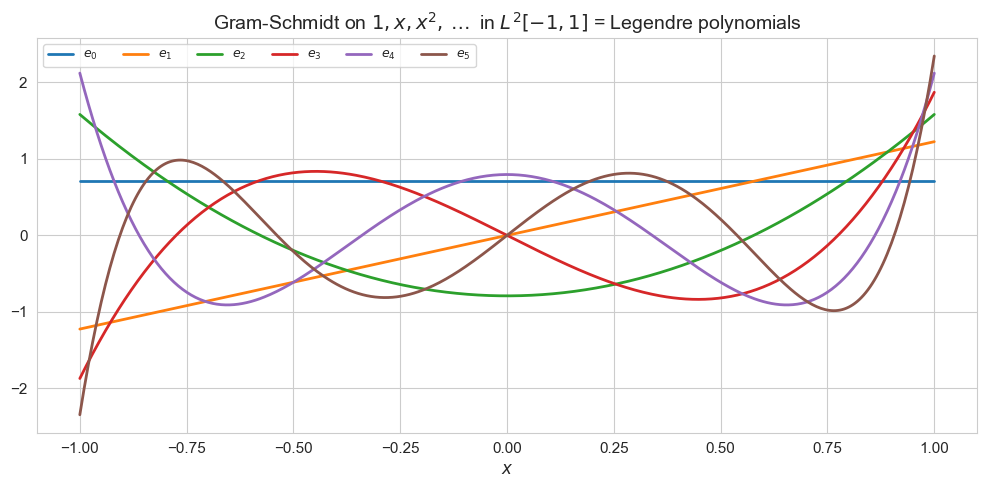

In [13]:
# Gram-Schmidt on monomials 1, x, x^2, ... in L^2[-1,1] gives the Legendre polynomials.
def l2_ip(f, g, lo=-1, hi=1):
    return quad(lambda t: f(t) * g(t), lo, hi, limit=200)[0]

monomials = [(lambda t, k=k: t ** k) for k in range(6)]
basis = []
for f in monomials:
    g = f
    for e in basis:                                  # subtract projections
        c = l2_ip(f, e)
        g = (lambda t, g=g, c=c, e=e: g(t) - c * e(t))
    nrm = np.sqrt(l2_ip(g, g))
    basis.append(lambda t, g=g, nrm=nrm: g(t) / nrm)

G = np.array([[l2_ip(a, b) for b in basis] for a in basis])
print("Gram matrix of the orthonormalised monomials (should be the identity):")
print(G)
print(f"\n||G - I|| = {sla_norm(G - np.eye(len(basis))):.2e}   -> orthonormal basis of P_5")

ts = np.linspace(-1, 1, 400)
fig, ax = plt.subplots(figsize=(10, 5))
for k, e in enumerate(basis):
    ax.plot(ts, [e(t) for t in ts], lw=2, label=f'$e_{k}$')
ax.set_title("Gram-Schmidt on $1,x,x^2,\\dots$ in $L^2[-1,1]$ = Legendre polynomials")
ax.legend(ncol=6, fontsize=9); ax.set_xlabel("$x$")
plt.tight_layout(); plt.show()

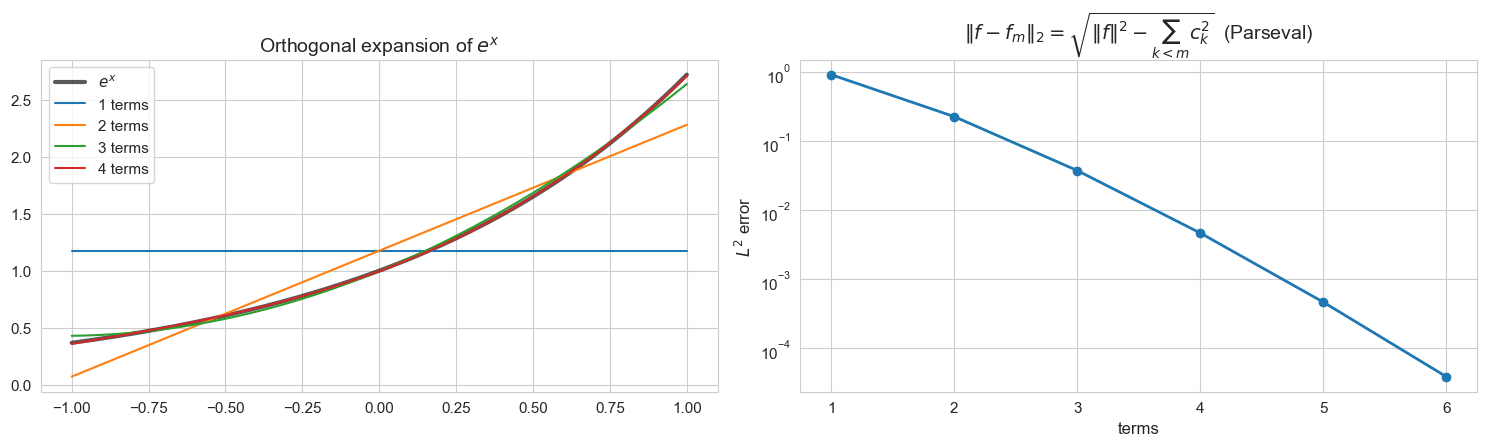

coefficients  c_k = <f, e_k>:
   c_0 = +1.661985
   c_1 = +0.901117
   c_2 = +0.226302
   c_3 = +0.037660
   c_4 = +0.004698
   c_5 = +0.000469

No linear system was solved. Each coefficient is one integral.
Adding a 7th basis function would NOT change c_0..c_5 -- that is orthogonality.


In [14]:
# The payoff: coefficients are just inner products. Approximate exp(x) on [-1,1].
target = np.exp
coeffs = [l2_ip(target, e) for e in basis]

def approx(t, m):
    return sum(coeffs[k] * basis[k](t) for k in range(m))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
axes[0].plot(ts, target(ts), 'k', lw=3, alpha=0.65, label='$e^x$')
for m in [1, 2, 3, 4]:
    axes[0].plot(ts, [approx(t, m) for t in ts], lw=1.5, label=f'{m} terms')
axes[0].legend(); axes[0].set_title("Orthogonal expansion of $e^x$")

errs = [np.sqrt(max(l2_ip(target, target) - sum(c**2 for c in coeffs[:m]), 1e-18))
        for m in range(1, 7)]
axes[1].semilogy(range(1, 7), errs, 'o-', lw=2)
axes[1].set_title(r"$\|f - f_m\|_2 = \sqrt{\|f\|^2 - \sum_{k<m} c_k^2}$  (Parseval)")
axes[1].set_xlabel("terms"); axes[1].set_ylabel("$L^2$ error")
plt.tight_layout(); plt.show()

print("coefficients  c_k = <f, e_k>:")
for k, c in enumerate(coeffs):
    print(f"   c_{k} = {c:+.6f}")
print("\nNo linear system was solved. Each coefficient is one integral.")
print("Adding a 7th basis function would NOT change c_0..c_5 -- that is orthogonality.")

### 6.4 What "converges" means in $L^2$ — and what it does not

Here is a subtlety worth having burned in, because it trips people up constantly.

The Fourier series of the square wave converges **in $L^2$**: $\|f - S_N\|_2 \to 0$.
It does **not** converge uniformly, and near the jump the overshoot never goes away —
about 9% of the jump height, forever. That is the **Gibbs phenomenon**.

Both statements are true simultaneously. Convergence is *relative to a norm*, and in a
Hilbert space the norm is the $L^2$ one. The overshoot survives but it lives on a shrinking
interval, so its *energy* $\to 0$.

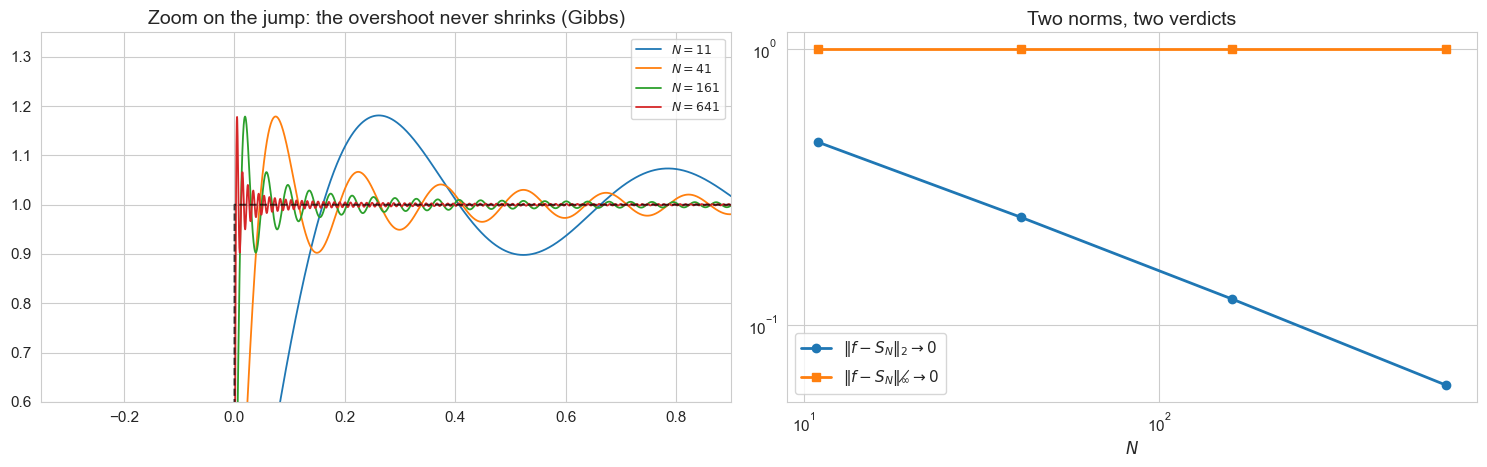

     N      L2 error     sup error   overshoot %
    11       0.45979       1.00000        18.13%
    41       0.24557       1.00000        17.92%
   161       0.12414       1.00000        17.90%
   641       0.06066       1.00000        17.83%

L2 error -> 0 while sup error stays ~1.18 and overshoot parks at ~8.9%.
'Converges' is meaningless until you say IN WHICH NORM.


In [15]:
xg = np.linspace(-np.pi, np.pi, 20001)
sq = np.sign(np.sin(xg))

def partial(N):
    out = np.zeros_like(xg)
    for k in range(1, N + 1, 2):
        out += (4 / (np.pi * k)) * np.sin(k * xg)
    return out

Ns = [11, 41, 161, 641]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for N in Ns:
    axes[0].plot(xg, partial(N), lw=1.3, label=f'$N={N}$')
axes[0].plot(xg, sq, 'k--', lw=1.4, alpha=0.7)
axes[0].set_xlim(-0.35, 0.9); axes[0].set_ylim(0.6, 1.35)
axes[0].set_title("Zoom on the jump: the overshoot never shrinks (Gibbs)")
axes[0].legend(fontsize=9)

l2err = [np.sqrt(trapz((partial(N) - sq) ** 2, xg)) for N in Ns]
supabs = [np.max(np.abs(partial(N) - sq)) for N in Ns]
axes[1].loglog(Ns, l2err, 'o-', lw=2, label=r'$\|f-S_N\|_2 \to 0$')
axes[1].loglog(Ns, supabs, 's-', lw=2, label=r'$\|f-S_N\|_\infty \not\to 0$')
axes[1].set_xlabel("$N$"); axes[1].legend(); axes[1].set_title("Two norms, two verdicts")
plt.tight_layout(); plt.show()

print(f"{'N':>6}  {'L2 error':>12}  {'sup error':>12}  {'overshoot %':>12}")
for N, e2, ei in zip(Ns, l2err, supabs):
    over = (partial(N).max() - 1) * 100
    print(f"{N:>6}  {e2:>12.5f}  {ei:>12.5f}  {over:>11.2f}%")
print("\nL2 error -> 0 while sup error stays ~1.18 and overshoot parks at ~8.9%.")
print("'Converges' is meaningless until you say IN WHICH NORM.")

### 6.5 Riesz representation — why bra-ket notation works

**Theorem (Riesz).** Every continuous linear functional $\varphi$ on a Hilbert space $H$
is an inner product with a *single fixed vector*: there is a unique $v_\varphi \in H$ with

$$\varphi(x) = \langle x, v_\varphi\rangle \quad \text{for all } x.$$

So $H$ is its own dual, $H \cong H^*$. In a general Banach space this is false, and the dual
is a genuinely different space (e.g. $(\ell^1)^* = \ell^\infty$, which is much bigger).

This is exactly what licenses Dirac's $\langle\psi|$ and $|\psi\rangle$ being two views of
the same object — see notebook 06.

In [16]:
# Every linear functional on R^n is "dot with some vector" -- find it by feeding basis vectors.
def phi(x):                       # some linear functional, defined abstractly
    return 3*x[0] - 2*x[1] + 0.5*x[2] + 4*x[3]

dim = 4
v_phi = np.array([phi(np.eye(dim)[i]) for i in range(dim)])   # the Riesz vector
print(f"Riesz representer v = {v_phi}")

rng = np.random.default_rng(11)
errs = [abs(phi(x := rng.normal(size=dim)) - x @ v_phi) for _ in range(1000)]
print(f"max |phi(x) - <x,v>| over 1000 random x : {max(errs):.2e}")
print("\nThe functional and the vector are the same object. That is Riesz.")

Riesz representer v = [ 3.  -2.   0.5  4. ]
max |phi(x) - <x,v>| over 1000 random x : 1.78e-15

The functional and the vector are the same object. That is Riesz.


---
## 7. Why none of this appears in a linear algebra course

Every distinction above is **invisible in finite dimensions**. Here it is, checked.

In [17]:
print("=== (a) In finite dim, ALL norms are equivalent ===")
print("    c1*||v||_a <= ||v||_b <= c2*||v||_a  for constants independent of v.")
rng = np.random.default_rng(5)
for d in [2, 10, 100]:
    V = rng.normal(size=(20000, d))
    r = np.array([pnorm(v, 1) / pnorm(v, 2) for v in V])
    print(f"    dim {d:>4}: ||v||_1/||v||_2 in [{r.min():.3f}, {r.max():.3f}]"
          f"   (theory: [1, sqrt({d})={np.sqrt(d):.3f}])")
print("    Bounded => the SAME sequences converge in every norm. One topology.")
print("    In infinite dim this fails: convergence in L1 does NOT imply convergence in L2.")

print("\n=== (b) In finite dim, closed+bounded => compact (Heine-Borel) ===")
print("    So the unit ball is compact and 'minimum is attained' comes for free.")
print("    In infinite dim the closed unit ball is NEVER compact (Riesz's lemma):")
d = 60
E = np.eye(d)                      # orthonormal, all on the unit sphere
dists = [sla_norm(E[i] - E[j]) for i in range(d) for j in range(i)]
print(f"    take e_1..e_{d}: all have ||e_i||=1, but pairwise distance is always"
      f" {np.unique(np.round(dists,10))[0]:.4f} = sqrt(2)")
print("    => no convergent subsequence => not compact. Existence proofs must work harder.")

=== (a) In finite dim, ALL norms are equivalent ===
    c1*||v||_a <= ||v||_b <= c2*||v||_a  for constants independent of v.
    dim    2: ||v||_1/||v||_2 in [1.000, 1.414]   (theory: [1, sqrt(2)=1.414])
    dim   10: ||v||_1/||v||_2 in [1.600, 3.110]   (theory: [1, sqrt(10)=3.162])


    dim  100: ||v||_1/||v||_2 in [6.762, 8.781]   (theory: [1, sqrt(100)=10.000])
    Bounded => the SAME sequences converge in every norm. One topology.
    In infinite dim this fails: convergence in L1 does NOT imply convergence in L2.

=== (b) In finite dim, closed+bounded => compact (Heine-Borel) ===
    So the unit ball is compact and 'minimum is attained' comes for free.
    In infinite dim the closed unit ball is NEVER compact (Riesz's lemma):


    take e_1..e_60: all have ||e_i||=1, but pairwise distance is always 1.4142 = sqrt(2)
    => no convergent subsequence => not compact. Existence proofs must work harder.


---
## 8. The surprises that only bite in infinite dimensions

### 8.1 Not every subspace is closed

In $\mathbb{R}^n$ every subspace is closed, so "closed subspace" in the projection theorem
reads like noise. In infinite dimensions it is the whole condition.

The polynomials are a subspace of $C[0,1]$, and by Weierstrass their closure is
*everything* — so the subspace of polynomials is **not closed**, and "project onto the
polynomials" has no best answer: you can always do better.

In [18]:
# Approximating |x - 0.5| on [0,1] by polynomials of growing degree: error -> 0,
# but the limit (the target) is not itself a polynomial. No minimiser exists in P.
xs2 = np.linspace(0, 1, 2001)
target2 = np.abs(xs2 - 0.5)

print(f"{'degree':>8}  {'best L2 error':>16}")
print("-" * 26)
prev = None
for deg in [1, 3, 5, 9, 15, 25, 40]:
    A = np.vander(xs2, deg + 1)
    c, *_ = np.linalg.lstsq(A, target2, rcond=None)
    err = np.sqrt(trapz((A @ c - target2) ** 2, xs2))
    print(f"{deg:>8}  {err:>16.3e}")
    prev = err
print("\nThe error keeps shrinking and never reaches zero at any finite degree.")
print("inf over the subspace is 0, but NO polynomial attains it.")
print("=> the subspace is not closed => the projection theorem does not apply.")
print("   In a Hilbert space with a CLOSED subspace, the minimiser always exists.")

  degree     best L2 error
--------------------------
       1         1.443e-01
       3         3.608e-02
       5         1.804e-02
       9         7.894e-03
      15         3.780e-03
      25         2.464e-03
      40         2.177e-03

The error keeps shrinking and never reaches zero at any finite degree.
inf over the subspace is 0, but NO polynomial attains it.
=> the subspace is not closed => the projection theorem does not apply.
   In a Hilbert space with a CLOSED subspace, the minimiser always exists.


/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_73750/177259358.py:12: RuntimeWarning: divide by zero encountered in matmul
  err = np.sqrt(trapz((A @ c - target2) ** 2, xs2))
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_73750/177259358.py:12: RuntimeWarning: overflow encountered in matmul
  err = np.sqrt(trapz((A @ c - target2) ** 2, xs2))
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_73750/177259358.py:12: RuntimeWarning: invalid value encountered in matmul
  err = np.sqrt(trapz((A @ c - target2) ** 2, xs2))


### 8.2 Summary of the hierarchy

| Structure | Gives you | Canonical failure without it |
|---|---|---|
| **Metric** | convergence, continuity | — |
| **Normed** | length, vector algebra | strings under edit distance: no $u+v$ |
| **Banach** | limits stay in the space | $(C[-1,1],\|\cdot\|_1)$: ramps $\to$ a step |
| **Inner product** | angles, orthogonality | $\|\cdot\|_1$: parallelogram law fails |
| **Hilbert** | all of it, in infinite dim | — |

$$\text{Metric} \;\supset\; \text{Normed} \;\supset\; \text{Banach} \;\supset\; \text{Hilbert}$$

and the containments are all **strict**: $\ell^1$ is Banach but not Hilbert,
$(C[-1,1],\|\cdot\|_1)$ is normed but not Banach, edit distance is a metric but not normed.

---
## 9. The ML payoff: the kernel trick *is* a Hilbert space

This is the section that makes the abstraction earn its keep for a practitioner.

A **kernel** $k(x,y)$ that is symmetric and positive semi-definite is, by
Moore–Aronszajn, **exactly an inner product in some Hilbert space**:

$$k(x,y) = \langle \phi(x), \phi(y)\rangle_{\mathcal{H}}$$

for some feature map $\phi$ into a space $\mathcal{H}$ (the **RKHS**) that you never have to
construct. "The kernel trick" is not a trick — it is the Riesz/Moore–Aronszajn theorem
being cashed in. The feature space is frequently infinite-dimensional, which is precisely
why you need Hilbert space rather than $\mathbb{R}^n$.

**Demonstration.** The polynomial kernel $k(x,y) = (x^\top y + 1)^2$ has an explicit finite
feature map, so we can check the identity directly.

In [19]:
def phi_poly2(x):
    # explicit feature map for k(x,y) = (<x,y> + 1)^2 in 2-D
    x1, x2 = x
    return np.array([1.0,
                     np.sqrt(2) * x1, np.sqrt(2) * x2,
                     x1 ** 2, x2 ** 2,
                     np.sqrt(2) * x1 * x2])

def k_poly2(x, y):
    return (x @ y + 1) ** 2

rng = np.random.default_rng(2)
pts = rng.normal(size=(6, 2))

K_kernel   = np.array([[k_poly2(a, b) for b in pts] for a in pts])
Phi        = np.array([phi_poly2(p) for p in pts])
K_explicit = Phi @ Phi.T

print("Gram matrix via the kernel function:")
print(K_kernel)
print("\nGram matrix via explicit features <phi(x), phi(y)>:")
print(K_explicit)
print(f"\nmax |difference| = {np.abs(K_kernel - K_explicit).max():.2e}")
print("\n2-D inputs -> 6-D feature space, and we never built it. That is the trick.")

Gram matrix via the kernel function:
[[ 1.7135  4.832   0.5508  0.2851  1.8028  1.8148]
 [ 4.832  50.8566  6.4355  0.5697  4.9996  1.8344]
 [ 0.5508  6.4355 30.781   1.6892  0.7611  5.7793]
 [ 0.2851  0.5697  1.6892  2.9059  0.2303  0.195 ]
 [ 1.8028  4.9996  0.7611  0.2303  1.9204  2.0935]
 [ 1.8148  1.8344  5.7793  0.195   2.0935  4.211 ]]

Gram matrix via explicit features <phi(x), phi(y)>:
[[ 1.7135  4.832   0.5508  0.2851  1.8028  1.8148]
 [ 4.832  50.8566  6.4355  0.5697  4.9996  1.8344]
 [ 0.5508  6.4355 30.781   1.6892  0.7611  5.7793]
 [ 0.2851  0.5697  1.6892  2.9059  0.2303  0.195 ]
 [ 1.8028  4.9996  0.7611  0.2303  1.9204  2.0935]
 [ 1.8148  1.8344  5.7793  0.195   2.0935  4.211 ]]

max |difference| = 3.55e-15

2-D inputs -> 6-D feature space, and we never built it. That is the trick.


In [20]:
# The RBF kernel's feature space is INFINITE-dimensional. We can still verify it is a
# legitimate inner product: the Gram matrix must be positive semi-definite (Mercer).
def k_rbf(x, y, gamma=0.7):
    return np.exp(-gamma * np.sum((x - y) ** 2))

pts2 = rng.normal(size=(80, 2))
K_rbf = np.array([[k_rbf(a, b) for b in pts2] for a in pts2])
eig = np.linalg.eigvalsh(K_rbf)

print(f"RBF Gram matrix, {K_rbf.shape[0]}x{K_rbf.shape[0]}")
print(f"   symmetric              : {np.allclose(K_rbf, K_rbf.T)}")
print(f"   smallest eigenvalue    : {eig.min():+.3e}")
print(f"   all eigenvalues >= 0   : {eig.min() > -1e-10}   -> positive semi-definite")
print("\nPSD is exactly the condition for 'this is an inner product in SOME Hilbert space'.")

# A NON-kernel: break symmetry/PSD and the Hilbert-space story collapses.
K_bad = np.array([[np.tanh(2 * (a @ b) + 1) for b in pts2] for a in pts2])
eb = np.linalg.eigvalsh((K_bad + K_bad.T) / 2)
print(f"\nsigmoid 'kernel' tanh(2<x,y>+1): smallest eigenvalue {eb.min():+.3e}")
print("   negative => NOT PSD => no Hilbert space => no guarantee of a unique SVM solution.")

RBF Gram matrix, 80x80
   symmetric              : True
   smallest eigenvalue    : +8.911e-12
   all eigenvalues >= 0   : True   -> positive semi-definite

PSD is exactly the condition for 'this is an inner product in SOME Hilbert space'.

sigmoid 'kernel' tanh(2<x,y>+1): smallest eigenvalue -1.059e+01
   negative => NOT PSD => no Hilbert space => no guarantee of a unique SVM solution.


/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_73750/2827134768.py:12: RuntimeWarning: divide by zero encountered in matmul
  pred = Kte @ alpha
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_73750/2827134768.py:12: RuntimeWarning: overflow encountered in matmul
  pred = Kte @ alpha
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_73750/2827134768.py:12: RuntimeWarning: invalid value encountered in matmul
  pred = Kte @ alpha


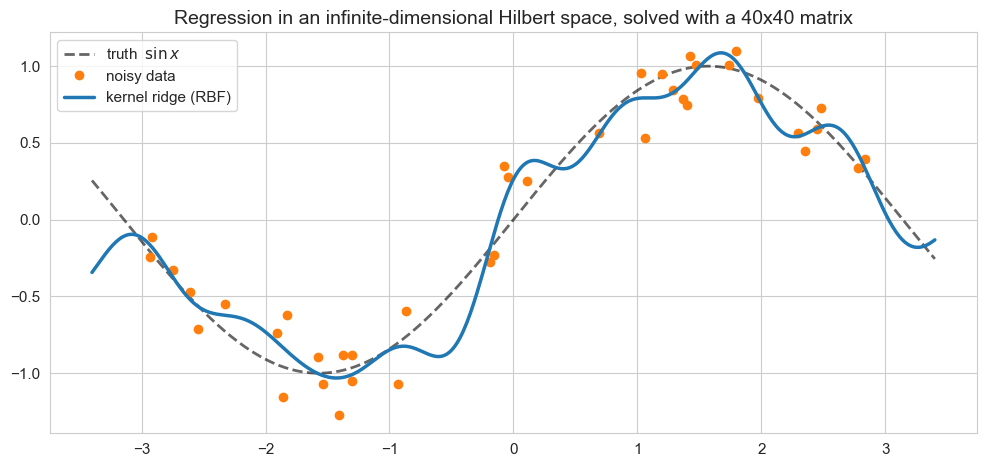

RMSE vs truth: 0.1518
The fit lives in an infinite-dim RKHS; the representer theorem collapses it
to a finite combination of kernels at the data points. That is a projection.


In [21]:
# Kernel ridge regression = projection in the RKHS. Same geometry as section 6.2.
def kernel_ridge_fit(Xtr, ytr, gamma=2.0, lam=1e-3):
    K = np.exp(-gamma * ((Xtr[:, None] - Xtr[None, :]) ** 2))
    return np.linalg.solve(K + lam * np.eye(len(Xtr)), ytr)

Xtr = np.sort(rng.uniform(-3, 3, 40))
ytr = np.sin(Xtr) + 0.15 * rng.normal(size=Xtr.size)
alpha = kernel_ridge_fit(Xtr, ytr)

Xte = np.linspace(-3.4, 3.4, 500)
Kte = np.exp(-2.0 * ((Xte[:, None] - Xtr[None, :]) ** 2))
pred = Kte @ alpha

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(Xte, np.sin(Xte), 'k--', lw=2, alpha=0.6, label='truth  $\\sin x$')
ax.plot(Xtr, ytr, 'o', color='C1', ms=6, label='noisy data')
ax.plot(Xte, pred, color='C0', lw=2.5, label='kernel ridge (RBF)')
ax.set_title("Regression in an infinite-dimensional Hilbert space, solved with a 40x40 matrix")
ax.legend(); plt.tight_layout(); plt.show()

print(f"RMSE vs truth: {np.sqrt(np.mean((pred - np.sin(Xte))**2)):.4f}")
print("The fit lives in an infinite-dim RKHS; the representer theorem collapses it")
print("to a finite combination of kernels at the data points. That is a projection.")

---
## 10. Where Lie algebras fit — a different axis entirely

Worth being blunt: **Lie theory is not another rung on the metric $\to$ Hilbert ladder.**
That ladder is about *how much geometry a space has*. Lie theory is about *linearising a
curved space of symmetries*.

| | Hilbert space | Lie algebra |
|---|---|---|
| Question | how do I do geometry in $\infty$ dimensions? | how do I do calculus on a curved **group**? |
| Object | a vector space with an inner product | the tangent space at the identity of a Lie group |
| Key operation | $\langle u,v\rangle$ | the commutator $[A,B]=AB-BA$ |
| Bridge | $\exp$ maps algebra $\to$ group | representations act **on** Hilbert spaces |

The motivating problem: $SO(3)$, the 3-D rotations, is a **group** but *not* a vector space.
Add two rotation matrices and you do not get a rotation. So you cannot do calculus,
gradient descent or interpolation on it directly.

The fix: work in the tangent space at the identity, $\mathfrak{so}(3)$ — the skew-symmetric
matrices. That **is** a vector space (flat, closed under $+$ and scaling), and $\exp$ maps it
back onto the group.

In [22]:
def hat(w):
    # map a 3-vector to a skew-symmetric matrix: element of so(3)
    return np.array([[    0, -w[2],  w[1]],
                     [ w[2],     0, -w[0]],
                     [-w[1],  w[0],     0]])

w1 = np.array([0.3, -0.2, 0.5])
w2 = np.array([-0.1, 0.4, 0.2])
A, B = hat(w1), hat(w2)

print("=== so(3) IS a vector space (flat) ===")
print(f"A + B skew-symmetric? {np.allclose((A+B).T, -(A+B))}")
print(f"3*A  skew-symmetric? {np.allclose((3*A).T, -(3*A))}")

R1, R2 = expm(A), expm(B)
print("\n=== SO(3) is NOT a vector space (curved) ===")
print(f"R1 a rotation?   R^T R = I : {np.allclose(R1.T @ R1, np.eye(3))},"
      f"  det = {np.linalg.det(R1):.6f}")
print(f"R1 + R2 a rotation? R^T R = I : {np.allclose((R1+R2).T @ (R1+R2), np.eye(3))},"
      f"  det = {np.linalg.det(R1+R2):.6f}   <-- broken")

print("\n=== exp maps the flat algebra onto the curved group ===")
print(f"exp(A) in SO(3)?  {np.allclose(expm(A).T @ expm(A), np.eye(3))}")
print(f"exp(A+B) == exp(A)exp(B)?  {np.allclose(expm(A+B), R1 @ R2)}   <-- only if they commute")

C = A @ B - B @ A
print(f"\ncommutator [A,B] = AB - BA still skew-symmetric? {np.allclose(C.T, -C)}")
print("   -> so(3) is CLOSED under the commutator. That closure is what makes it")
print("      a Lie algebra rather than just a vector space.")
print(f"\n[A,B] corresponds to the cross product w1 x w2:")
print(f"   from commutator : {np.array([C[2,1], C[0,2], C[1,0]])}")
print(f"   w1 x w2         : {np.cross(w1, w2)}")

=== so(3) IS a vector space (flat) ===
A + B skew-symmetric? True
3*A  skew-symmetric? True

=== SO(3) is NOT a vector space (curved) ===
R1 a rotation?   R^T R = I : True,  det = 1.000000
R1 + R2 a rotation? R^T R = I : False,  det = 6.852876   <-- broken

=== exp maps the flat algebra onto the curved group ===
exp(A) in SO(3)?  True
exp(A+B) == exp(A)exp(B)?  False   <-- only if they commute

commutator [A,B] = AB - BA still skew-symmetric? True
   -> so(3) is CLOSED under the commutator. That closure is what makes it
      a Lie algebra rather than just a vector space.

[A,B] corresponds to the cross product w1 x w2:
   from commutator : [-0.24 -0.11  0.1 ]
   w1 x w2         : [-0.24 -0.11  0.1 ]


In [23]:
# Why practitioners care: interpolating rotations. Naive averaging leaves the group;
# averaging in the Lie algebra and mapping back does not.
wa, wb = np.array([0.0, 0.0, 0.0]), np.array([0.0, 0.0, np.pi * 0.9])
Ra, Rb = expm(hat(wa)), expm(hat(wb))

ts = np.linspace(0, 1, 9)
naive  = [(1 - t) * Ra + t * Rb for t in ts]                 # linear in the group: WRONG
lie    = [expm(hat((1 - t) * wa + t * wb)) for t in ts]      # linear in the algebra: RIGHT

print(f"{'t':>5}  {'naive det':>12}  {'naive ortho err':>18}  {'Lie det':>10}  {'Lie ortho err':>15}")
print("-" * 70)
for t, Na, Li in zip(ts, naive, lie):
    print(f"{t:>5.2f}  {np.linalg.det(Na):>12.5f}  "
          f"{sla_norm(Na.T@Na - np.eye(3)):>18.5f}  "
          f"{np.linalg.det(Li):>10.5f}  {sla_norm(Li.T@Li - np.eye(3)):>15.2e}")
print("\nNaive interpolation leaves SO(3) (det shrinks, orthogonality breaks).")
print("Interpolating in so(3) and exponentiating stays exactly on the group.")
print("This is why robotics/graphics/pose estimation optimise in the Lie algebra.")

    t     naive det     naive ortho err     Lie det    Lie ortho err
----------------------------------------------------------------------
 0.00       1.00000             0.00000     1.00000         0.00e+00
 0.12       0.57321             0.60358     1.00000         8.19e-17
 0.25       0.26835             1.03470     1.00000         2.50e-16
 0.38       0.08544             1.29338     1.00000         2.78e-16
 0.50       0.02447             1.37961     1.00000         1.17e-16
 0.62       0.08544             1.29338     1.00000         4.65e-16
 0.75       0.26835             1.03470     1.00000         3.94e-15
 0.88       0.57321             0.60358     1.00000         6.12e-15
 1.00       1.00000             0.00000     1.00000         6.91e-15

Naive interpolation leaves SO(3) (det shrinks, orthogonality breaks).
Interpolating in so(3) and exponentiating stays exactly on the group.
This is why robotics/graphics/pose estimation optimise in the Lie algebra.


**Where the two axes meet.** A Lie group can *act* on a Hilbert space. Those actions are
**representations**, and that is the entire mathematical content of "symmetry" in quantum
mechanics: $SO(3)$ acting on $L^2(\mathbb{R}^3)$ gives angular momentum, the spherical
harmonics are the orthonormal basis that decomposes it, and the commutator
$[\hat L_x, \hat L_y] = i\hbar \hat L_z$ **is** the $\mathfrak{so}(3)$ bracket computed above.
Notebook 06 picks this up.

*Lie theory deserves its own notebook — this section is the orientation, not the treatment.*

---
## 11. Summary — the answers, stripped

**Q: What does a Hilbert space give me over ordinary linear algebra?**
Nothing, in finite dimensions — they coincide. In infinite dimensions it gives you
*permission to keep using your finite-dimensional intuition*: angles, orthogonality,
projection, Pythagoras and countable bases all still work. Every one of those fails in a
general Banach space.

**Q: How is the inner product different from the dot product I already know?**
It is not. $\langle u,v\rangle = \|u\|\|v\|\cos\theta$ throughout. The abstraction exists to
identify the *minimum assumptions* under which that formula still means something when
$u$ and $v$ are functions or random variables.

**Q: What is the actual difference between Banach and Hilbert?**
One equation — the parallelogram law. If the norm satisfies it, an inner product exists
and you get geometry. If not, you have lengths but no angles. Only $p=2$ passes (§5.1).

**Q: Why does any of this matter in practice?**

| Because... | You get |
|---|---|
| $L^2$ is complete | Fourier series converge to something that exists |
| the projection theorem holds | least squares has a **unique** solution |
| orthonormal bases exist | coefficients are inner products, not a linear solve |
| PSD kernels are inner products | the kernel trick, SVMs, Gaussian processes, RKHS |
| Riesz representation holds | bra-ket notation; adjoints; Lax–Milgram for PDEs |

**The thing to remember.** The hierarchy is not a taxonomy for its own sake. Each layer is
the answer to "what broke?" — and in finite dimensions nothing ever breaks, which is
exactly why the definitions look unmotivated when you first meet them.

---

### Where to go next

- **Notebook 05** — measure theory; how $L^p$ spaces are actually constructed, and why $L^2$
  is complete (Riesz–Fischer).
- **Notebook 06** — quantum mechanics; Hilbert spaces used in anger, self-adjoint operators,
  the spectral theorem.
- **Notebook 03/03a** — eigendecomposition and SVD, which are the finite-dimensional
  shadow of the spectral theorem.

### References

- Kreyszig, *Introductory Functional Analysis with Applications* — the readable standard.
- Rudin, *Real and Complex Analysis* — ch. 4 for Hilbert spaces.
- Schölkopf & Smola, *Learning with Kernels* — RKHS for ML.
- Hall, *Lie Groups, Lie Algebras, and Representations* — for §10.